# Announcement uplift: did the FIFA partnership raise Lenovo's brand salience?

**Review notebook** for the sponsorship counterfactual (`sponsorship_counterfactual_v1`), its pre-period design re-selection (`announcement_design_selection_v1` / `_v2`) and the media-value weighting sensitivity. It follows the human-review standard in `AGENTS.md`.

*How to use:* run all cells. The notebook only reads production outputs and calls production functions; it never rewrites data unless `RUN_REBUILD` is set to `True` in the first code cell. Every number in the narrative below is computed from the current outputs when the notebook runs.

In [1]:
# Setup: read-only by default (AGENTS.md). Nothing below rewrites data unless RUN_REBUILD is True.
RUN_REBUILD = False   # set True only to regenerate the production outputs this notebook reads

import json, os, subprocess, sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "srmp").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from srmp.review import stamp_sources

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.figsize": (10, 4.2), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

def md(text):
    display(Markdown(text))

def fmt(value, digits=2, signed=False):
    return f"{value:+.{digits}f}" if signed else f"{value:.{digits}f}"

if RUN_REBUILD:  # explicit opt-in: regenerates the outputs read below (several minutes)
    for module, *args in [("srmp.experiments.sponsorship_counterfactual_v1",),
                          ("srmp.experiments.announcement_design_selection_v1",),
                          ("srmp.experiments.announcement_design_selection_v1", "--config",
                           "config/experiments/announcement_design_selection_v2.yaml")]:
        subprocess.run([sys.executable, "-m", module, *args], check=True)

E = "data/curated/experimental/"
SOURCES = [
    "data/curated/index/brand_index_weekly.parquet",
    "data/curated/trends/jointly_scaled_donor_trends.parquet",
    "data/reference/counterfactual_donor_registry.csv",
    E + "sponsorship_counterfactual_v1/counterfactual_manifest.json",
    E + "sponsorship_counterfactual_v1/counterfactual_weekly.parquet",
    E + "sponsorship_counterfactual_v1/donor_placebos.parquet",
    E + "sponsorship_counterfactual_v1/media_value_intensity_sensitivity.json",
    E + "announcement_design_selection_v1/estimate_manifest.json",
    E + "announcement_design_selection_v2/selection_record.json",
    E + "announcement_design_selection_v2/selection_table.parquet",
    E + "announcement_design_selection_v2/estimate_manifest.json",
    E + "announcement_design_selection_v2/specification_curve.parquet",
    "config/experiments/sponsorship_counterfactual_v1.yaml",
    "config/experiments/announcement_design_selection_v2.yaml",
]
stamp_sources(SOURCES)

REVIEW_SOURCES={"data/curated/index/brand_index_weekly.parquet": "5acb22608f2dbbd19acd50d3f1378dd7f3f92e957dcb282c2e729c5fe5ee4449", "data/curated/trends/jointly_scaled_donor_trends.parquet": "d03dea0cf14b0af202f704502829d0801ba2763df187b0be17881f1309aaf4a7", "data/reference/counterfactual_donor_registry.csv": "d3e93f01eeca4b42c4f6cfb0734b6ff10687e83014cbc8633f40b3d157972475", "data/curated/experimental/sponsorship_counterfactual_v1/counterfactual_manifest.json": "592fe6a6634775545c337c16b3349019b68d501555301ec2377e7fe5d27892c7", "data/curated/experimental/sponsorship_counterfactual_v1/counterfactual_weekly.parquet": "6326f216c8f8b83708829a2d325f5dd30bc8c424707f0369397e09f83a7906db", "data/curated/experimental/sponsorship_counterfactual_v1/donor_placebos.parquet": "f45b0085985493537660e1d4d70b67b51ae819936f20e1eb1893ec3b3869e5e6", "data/curated/experimental/sponsorship_counterfactual_v1/media_value_intensity_sensitivity.json": "eda2225fbd08945935e8cb7ddc96aceb78262739bbaab327c46eec42ff

,file,sha256,last_generated_utc,size_kb
0,data/curated/index/brand_index_weekly.parquet,5acb22608f2d,NaN,7.2
1,data/curated/trends/jointly_scaled_donor_trend...,d03dea0cf14b,NaN,22.9
2,data/reference/counterfactual_donor_registry.csv,d3e93f01eeca,NaN,13.4
3,data/curated/experimental/sponsorship_counterf...,592fe6a66347,2026-10-06T13:22:36.653403+00:00,5.8
4,data/curated/experimental/sponsorship_counterf...,6326f216c8f8,NaN,25.3
5,data/curated/experimental/sponsorship_counterf...,f45b00859854,NaN,3.4
6,data/curated/experimental/sponsorship_counterf...,eda2225fbd08,NaN,3.1
7,data/curated/experimental/announcement_design_...,a3eedf31eb52,2026-10-06T13:22:48.062852+00:00,4.3
8,data/curated/experimental/announcement_design_...,42727345633f,2026-10-06T13:23:03.229589+00:00,2.5
9,data/curated/experimental/announcement_design_...,106cac036e7b,NaN,5.6


## 1. Question and purpose

**Question.** Since Lenovo announced its FIFA partnership on 15 October 2024, has its brand salience risen above what it would have been without the partnership?

**Why it matters.** Every later step of the project (World Cup impact, brand value, return on the sponsorship) needs a sponsorship-attributable change in Lenovo's brand position. If no lift can be separated from normal market movement, nothing downstream can be attributed to the sponsorship.

**Objective supported.** Measuring the brand uplift from the sponsorship (the "lift" layer of the project), before any monetisation.

## 2. Evidence and inputs

| Input | What it is | Source | Label |
|---|---|---|---|
| Lenovo Brand Index | Weekly brand-salience index on a 100/15 display scale. Weekly movement comes 100% from worldwide Google Trends interest in "Lenovo"; GWI survey waves only orient and scale it | Google Trends; GWI | **constructed** (proxy-led index) |
| Competitor ("donor") brands | Weekly Google Trends interest for rival tech brands, pulled in panels that share a common "Lenovo" anchor so all brands sit on one scale | Google Trends | **observed**, then **constructed** (common-anchor rescaling) |
| Donor registry | Which brands are allowed as comparisons, after screening for FIFA/World Cup sponsorship and data quality | FIFA partner lists, brand news, our screen | **assumed** (evidence-bounded: absence of a found sponsorship is not proof) |
| FIFA exposure | Weekly digital/social impressions of Lenovo's FIFA properties | Blinkfire (client export) | **observed** (digital only; no broadcast) |
| Media value | Vendor media-equivalency value by FIFA competition and market, used only as a relative weight | Client media-value export | **estimated** by the vendor; used as **constructed** relative intensity |

The next cell shows the coverage of each input as currently stored.

In [2]:
index = pd.read_parquet("data/curated/index/brand_index_weekly.parquet")
donors = pd.read_parquet("data/curated/trends/jointly_scaled_donor_trends.parquet")
registry = pd.read_csv("data/reference/counterfactual_donor_registry.csv")
weekly = pd.read_parquet(E + "sponsorship_counterfactual_v1/counterfactual_weekly.parquet")
weekly["week"] = pd.to_datetime(weekly["week"])
coverage = pd.DataFrame([
    {"Input": "Lenovo Brand Index (weeks, Monday start)", "First": index["week"].min(), "Last": index["week"].max(), "Rows": len(index)},
    {"Input": "Donor panels (Trends weeks, Sunday start)", "First": donors["week"].min(), "Last": donors["week"].max(),
     "Rows": donors["query_id"].nunique()},
    {"Input": "Weeks with FIFA exposure > 0 (Blinkfire)", "First": weekly.loc[weekly["fifa_impressions"] > 0, "week"].min(),
     "Last": weekly.loc[weekly["fifa_impressions"] > 0, "week"].max(), "Rows": int((weekly["fifa_impressions"] > 0).sum())},
])
coverage["Rows"] = coverage["Rows"].astype(int)
display(coverage.rename(columns={"Rows": "Rows (weeks; donors = queries)"}))
policy = registry["inclusion_policy"].value_counts().rename_axis("Donor registry policy").rename("Brands")
display(policy.to_frame())

,Input,First,Last,Rows (weeks; donors = queries)
0,"Lenovo Brand Index (weeks, Monday start)",2022-01-03,2026-09-28,248
1,"Donor panels (Trends weeks, Sunday start)",2021-12-26,2026-09-27,38
2,Weeks with FIFA exposure > 0 (Blinkfire),2024-10-14 00:00:00,2026-07-20 00:00:00,70


,Brands
Donor registry policy,
candidate_base,15
base,11
data_quality_excluded,7
excluded,2
sensitivity,2


**Reading the registry.** `base` donors were screened clean in the July 2026 design (ADR-0021); `candidate_base` donors were added and screened in October 2026 (ADR-0035); `sensitivity` donors (Huawei, MSI) are only used in robustness checks; `excluded` brands had FIFA or World Cup activity; `data_quality_excluded` brands had mostly empty or constant search series.

## 3. Method and formulas

**Synthetic control.** Lenovo cannot be observed without the sponsorship, so we build a "synthetic Lenovo" from a weighted mix of rival brands that tracked Lenovo closely *before* the announcement, and read its post-announcement path as Lenovo's no-sponsorship path.

All series are first standardised with their own pre-announcement mean and standard deviation (so post-announcement data never influence scaling). For Lenovo $y_t$ and donors $x_{jt}$ in these standardised units, the simplex weights solve

$$\hat w = \arg\min_{w} \sum_{t < T_0} \Big(y_t - \sum_j w_j x_{jt}\Big)^2 \quad \text{s.t. } w_j \ge 0,\ \sum_j w_j = 1 .$$

*In words:* find the non-negative mix of rival brands, adding up to 100%, that best reproduces Lenovo's weekly salience before the announcement week $T_0$ = 21 October 2024 (the first full week after the 15 October announcement).

The **gap** in Brand Index points is

$$\text{gap}_t = \sigma_y \Big(y_t - \sum_j \hat w_j x_{jt}\Big),$$

where $\sigma_y$ is Lenovo's pre-announcement standard deviation in Index points. *In words:* how far Lenovo sits above (+) or below (−) its synthetic twin each week. The **lift** is the mean gap over the post-announcement weeks (excluding the last two weeks of the data pull, which Google still revises).

**Other estimators** used for robustness (`srmp/counterfactual/scm.py`): *augmented SCM* corrects the simplex fit with a ridge regression, $\gamma = \hat w + (X_0X_0' + \lambda I)^{-1}X_0(y_{pre} - X_0'\hat w)$, so weights may extrapolate beyond the rival brands; *synthetic difference-in-differences* also re-weights pre-period weeks and allows a level difference; the *generalized SCM factor model* lets Lenovo have its own sensitivity to common factors extracted from the donors.

**Placebo test.** Each rival brand is treated in turn as if it had been sponsored, and its own synthetic twin is built from the other rivals. The test statistic is the post/pre RMSPE ratio

$$R = \frac{\sqrt{\text{mean}_{t \ge T_0}\, \text{gap}_t^2}}{\sqrt{\text{mean}_{t < T_0}\, \text{gap}_t^2}}, \qquad p = \frac{1 + \#\{\text{placebos with } R_j \ge R_{Lenovo}\}}{1 + J}.$$

*In words:* how much more Lenovo diverges from its twin after the announcement than before, compared with how much each rival diverges from its own twin. With $J$ placebos the smallest possible $p$ is $1/(1+J)$. The project's significance threshold is $p \le 0.10$. A secondary statistic, *mean post gap ÷ pre RMSPE*, targets a sustained one-directional shift.

**Design selection on pre-period evidence only.** Because the original test failed, the design (method × donor pool) was re-chosen *without looking at post-announcement data*: each candidate predicts Lenovo in four rolling 16-week pre-period folds, and the lowest out-of-sample error wins (ADR-0034, ADR-0035).

## 4. Calculation path

| Step | Reproducible code | Configuration | Output read here |
|---|---|---|---|
| Pull Lenovo and donor Trends panels | `srmp/ingest/trends.py`, `srmp/ingest/trends_joint.py` | `config/queries_trends.yaml`, `config/joint_trends_donors.yaml` | `data/curated/trends/` |
| Build the Brand Index | `srmp/index/proxy_led.py` | `config/base.yaml` | `data/curated/index/brand_index_weekly.parquet` |
| Adstocked FIFA exposure | `srmp/experiments/sponsorship_monetization_v1.py` (`build_adstock_exposure`) | `config/experiments/sponsorship_monetization_v1.yaml` | `exposure_adstock_weekly` |
| Original synthetic control + placebos + media-value sensitivity | `srmp/experiments/sponsorship_counterfactual_v1.py` | `config/experiments/sponsorship_counterfactual_v1.yaml` | `sponsorship_counterfactual_v1/` |
| Pre-period design selection, single estimate, specification curve | `srmp/experiments/announcement_design_selection_v1.py` (`select_design`, `build`) using `srmp/counterfactual/scm.py` | `config/experiments/announcement_design_selection_v1.yaml`, `_v2.yaml` | `announcement_design_selection_v1/`, `_v2/` |
| Rebuild everything in order | `python -m srmp.pipeline` | — | — |

## 5. Results

### 5.1 The original synthetic control (11 donors, July 2026 design)

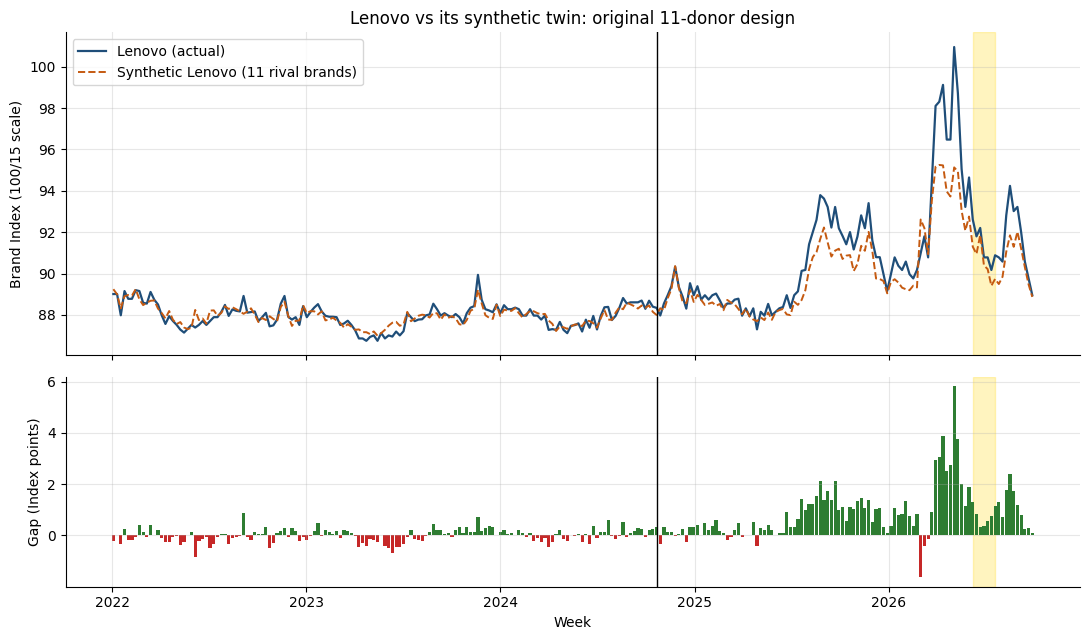

**Figure 1.** Vertical line: first full week after the announcement (21 Oct 2024). Gold band: Men's World Cup. Before the announcement the twin tracks Lenovo with a root-mean-square error of 0.26 Index points; afterwards the gap is mostly positive. The test below asks whether that is unusual.

In [3]:
cf = json.loads(Path(E + "sponsorship_counterfactual_v1/counterfactual_manifest.json").read_text())
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True, gridspec_kw={"height_ratios": [2, 1.3]})
ax1.plot(weekly["week"], weekly["actual_index"], label="Lenovo (actual)", color="#1f4e79", lw=1.6)
ax1.plot(weekly["week"], weekly["synthetic_index"], label="Synthetic Lenovo (11 rival brands)", color="#c55a11", lw=1.4, ls="--")
for a in (ax1, ax2):
    a.axvline(pd.Timestamp("2024-10-21"), color="black", lw=1)
    a.axvspan(pd.Timestamp("2026-06-08"), pd.Timestamp("2026-07-19"), color="gold", alpha=0.25)
ax1.set_ylabel("Brand Index (100/15 scale)")
ax1.set_title("Lenovo vs its synthetic twin: original 11-donor design")
ax1.legend(loc="upper left")
ax2.bar(weekly["week"], weekly["index_gap"], width=6, color=np.where(weekly["index_gap"] >= 0, "#2e7d32", "#c62828"))
ax2.set_ylabel("Gap (Index points)")
ax2.set_xlabel("Week")
plt.tight_layout(); plt.show()
d = cf["diagnostics"]
md(f"**Figure 1.** Vertical line: first full week after the announcement (21 Oct 2024). Gold band: Men's World Cup. "
   f"Before the announcement the twin tracks Lenovo with a root-mean-square error of {fmt(d['pre_rmspe_index_points'])} Index points; "
   f"afterwards the gap is mostly positive. The test below asks whether that is unusual.")

In [4]:
phases = [("Before the announcement", "2022-01-01", "2024-10-14"),
          ("Announcement quarter", "2024-10-15", "2024-12-31"),
          ("Early 2025", "2025-01-01", "2025-06-08"),
          ("Club World Cup 2025", "2025-06-09", "2025-07-13"),
          ("H2 2025 (U-17, U-20 World Cups)", "2025-07-14", "2025-12-31"),
          ("Q1 2026 (CES)", "2026-01-01", "2026-03-15"),
          ("Spring 2026 PC-price surge (confounded)", "2026-03-16", "2026-06-07"),
          ("Men's World Cup", "2026-06-08", "2026-07-19"),
          ("After the final (excl. 2 provisional weeks)", "2026-07-20", str(weekly["week"].iloc[-3].date()))]
table = pd.DataFrame([{"Phase": name, "From": a, "To": b,
                       "Weeks": int(((weekly["week"] >= a) & (weekly["week"] <= b)).sum()),
                       "Mean gap (Index points)": weekly.loc[(weekly["week"] >= a) & (weekly["week"] <= b), "index_gap"].mean()}
                      for name, a, b in phases])
display(table.style.format({"Mean gap (Index points)": "{:+.2f}"}).hide(axis="index"))
md("**Table 1.** Mean gap by phase, original design. The lift builds gradually rather than jumping at the announcement. "
   "The spring 2026 phase coincides with a category-wide surge in PC-brand searches (section 5.5) and should not be read as sponsorship effect.")

Phase,From,To,Weeks,Mean gap (Index points)
Before the announcement,2022-01-01,2024-10-14,146,+0.00
Announcement quarter,2024-10-15,2024-12-31,11,+0.11
Early 2025,2025-01-01,2025-06-08,22,+0.18
Club World Cup 2025,2025-06-09,2025-07-13,5,+0.35
"H2 2025 (U-17, U-20 World Cups)",2025-07-14,2025-12-31,25,+1.16
Q1 2026 (CES),2026-01-01,2026-03-15,10,+0.44
Spring 2026 PC-price surge (confounded),2026-03-16,2026-06-07,12,+2.55
Men's World Cup,2026-06-08,2026-07-19,6,+0.70
After the final (excl. 2 provisional weeks),2026-07-20,2026-09-14,9,+1.26


**Table 1.** Mean gap by phase, original design. The lift builds gradually rather than jumping at the announcement. The spring 2026 phase coincides with a category-wide surge in PC-brand searches (section 5.5) and should not be read as sponsorship effect.

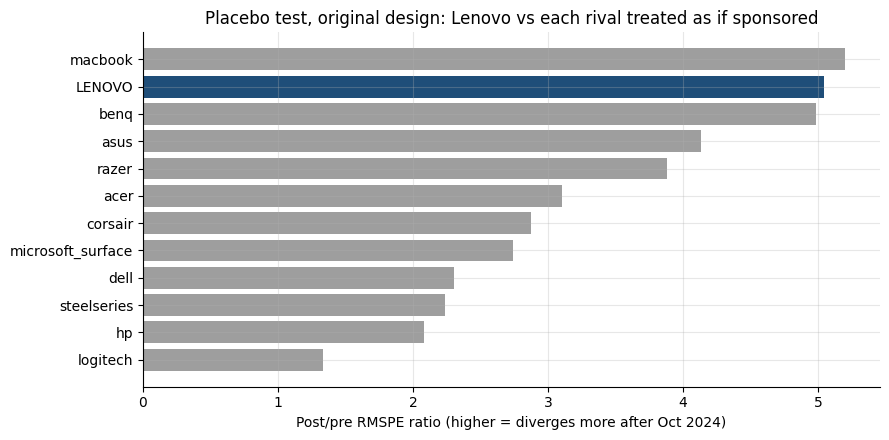

**Figure 2.** Lenovo ranks behind 1 of 11 rival brands, so p = 0.167 (threshold 0.10): **not distinguishable** from ordinary brand drift with this design.

In [5]:
pl = pd.read_parquet(E + "sponsorship_counterfactual_v1/donor_placebos.parquet")
ratios = pd.concat([pl[["placebo_unit", "post_pre_rmspe_ratio"]],
                    pd.DataFrame([{"placebo_unit": "LENOVO", "post_pre_rmspe_ratio": d["post_pre_rmspe_ratio"]}])])
ratios = ratios.sort_values("post_pre_rmspe_ratio")
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(ratios["placebo_unit"].str.replace("donor_", ""), ratios["post_pre_rmspe_ratio"],
        color=["#1f4e79" if u == "LENOVO" else "#9e9e9e" for u in ratios["placebo_unit"]])
ax.set_xlabel("Post/pre RMSPE ratio (higher = diverges more after Oct 2024)")
ax.set_title("Placebo test, original design: Lenovo vs each rival treated as if sponsored")
plt.tight_layout(); plt.show()
md(f"**Figure 2.** Lenovo ranks behind {int((pl['post_pre_rmspe_ratio'] >= d['post_pre_rmspe_ratio']).sum())} of {len(pl)} rival brands, "
   f"so p = {fmt(d['donor_placebo_p_value'], 3)} (threshold 0.10): **not distinguishable** from ordinary brand drift with this design.")

### 5.2 Re-selecting the design on pre-period evidence only

The selection below used only weeks before 21 October 2024 (asserted by the selection record) and included the 15 additional screened donor brands.

In [6]:
record = json.loads(Path(E + "announcement_design_selection_v2/selection_record.json").read_text())
sel = pd.read_parquet(E + "announcement_design_selection_v2/selection_table.parquet")
show = sel.rename(columns={"donor_pool": "Donor pool", "method": "Method", "donors": "Donors",
                           "oos_rmspe_index_points": "Out-of-sample RMSE (Index pts)",
                           "oos_mean_error_index_points": "Mean error (Lenovo above twin, pts)",
                           "worst_fold_mean_error": "Worst fold mean error"})
display(show.drop(columns=["folds"]).head(10).style.format(precision=3).hide(axis="index"))
md(f"**Table 2.** Ten best of {len(sel)} candidate designs, scored on four 16-week pre-announcement folds "
   f"(data seen: {record['data_weeks_seen'][0]} to {record['data_weeks_seen'][1]}; post-period accessed: {record['post_period_outcomes_accessed']}). "
   f"Selected by rule: **{record['selected_method']} on the '{record['selected_pool']}' pool ({len(record['selected_donors'])} donors)**. "
   f"Every design under-predicts Lenovo slightly even before the announcement (positive mean error), i.e. Lenovo was already drifting up a little.")

Donor pool,Method,Donors,Out-of-sample RMSE (Index pts),"Mean error (Lenovo above twin, pts)",Worst fold mean error
expanded,simplex_scm,26,0.288,0.096,0.303
expanded_plus_sensitivity,simplex_scm,28,0.288,0.096,0.303
expanded_plus_sensitivity,augmented_scm,28,0.292,0.108,0.350
expanded,synthetic_did,26,0.304,0.078,0.269
expanded,augmented_scm,26,0.307,0.105,0.378
base_plus_sensitivity,synthetic_did,13,0.308,0.195,0.343
base,augmented_scm,11,0.313,0.184,0.311
expanded_plus_sensitivity,generalized_scm_factor,28,0.313,0.121,0.325
expanded_plus_sensitivity,synthetic_did,28,0.319,0.130,0.334
expanded_parallel_trend_screened,augmented_scm,14,0.320,0.090,0.251


**Table 2.** Ten best of 24 candidate designs, scored on four 16-week pre-announcement folds (data seen: 2022-01-03 to 2024-10-14; post-period accessed: False). Selected by rule: **simplex_scm on the 'expanded' pool (26 donors)**. Every design under-predicts Lenovo slightly even before the announcement (positive mean error), i.e. Lenovo was already drifting up a little.

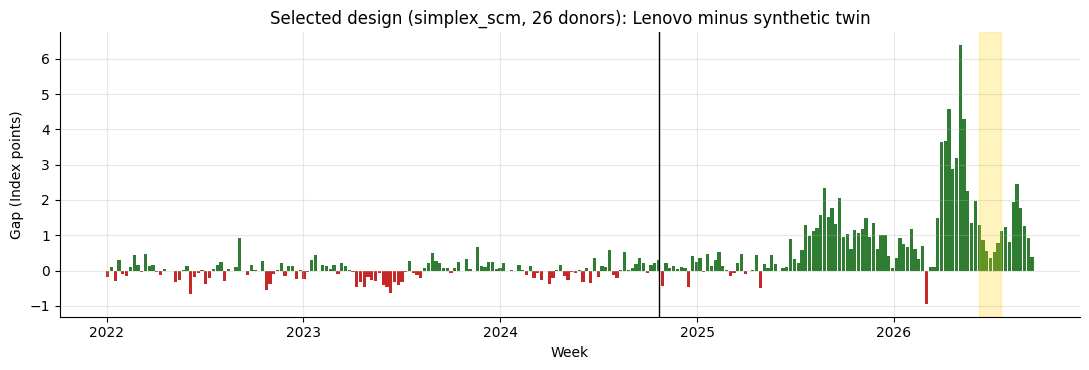

**Figure 3.** Weekly gap under the pre-selected design (recomputed here with the production estimator and checked against the stored estimate). Post-announcement lift: **+0.91 Index points**; pre-announcement fit error 0.25 points.

In [7]:
from srmp.experiments import announcement_design_selection_v1 as selection
from srmp.experiments.world_cup_impact_v1_estimator import _fit_methods
import yaml
cfg2 = yaml.safe_load(Path("config/experiments/announcement_design_selection_v2.yaml").read_text(encoding="utf-8"))
panel, groups = selection._load_panel(cfg2)
pre = np.asarray(panel.index < pd.Timestamp("2024-10-21"))
target = panel["index_level"].to_numpy(float)
pool = panel[record["selected_donors"]].to_numpy(float)
fits, _, _, sd = _fit_methods(target, pool, pre, ~pre, cfg2)   # same production call as the experiment
gap = fits[record["selected_method"]].gap_z * sd
est = json.loads(Path(E + "announcement_design_selection_v2/estimate_manifest.json").read_text())
assert np.isclose(gap[~pre].mean(), est["primary"]["lift_index_points"]), "notebook path must match the stored estimate"
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.bar(panel.index, gap, width=6, color=np.where(gap >= 0, "#2e7d32", "#c62828"))
ax.axvline(pd.Timestamp("2024-10-21"), color="black", lw=1)
ax.axvspan(pd.Timestamp("2026-06-08"), pd.Timestamp("2026-07-19"), color="gold", alpha=0.25)
ax.set_ylabel("Gap (Index points)"); ax.set_xlabel("Week")
ax.set_title(f"Selected design ({record['selected_method']}, {len(record['selected_donors'])} donors): Lenovo minus synthetic twin")
plt.tight_layout(); plt.show()
p = est["primary"]
md(f"**Figure 3.** Weekly gap under the pre-selected design (recomputed here with the production estimator and checked against the stored estimate). "
   f"Post-announcement lift: **{fmt(p['lift_index_points'], signed=True)} Index points**; pre-announcement fit error {fmt(p['pre_rmspe_index_points'])} points.")

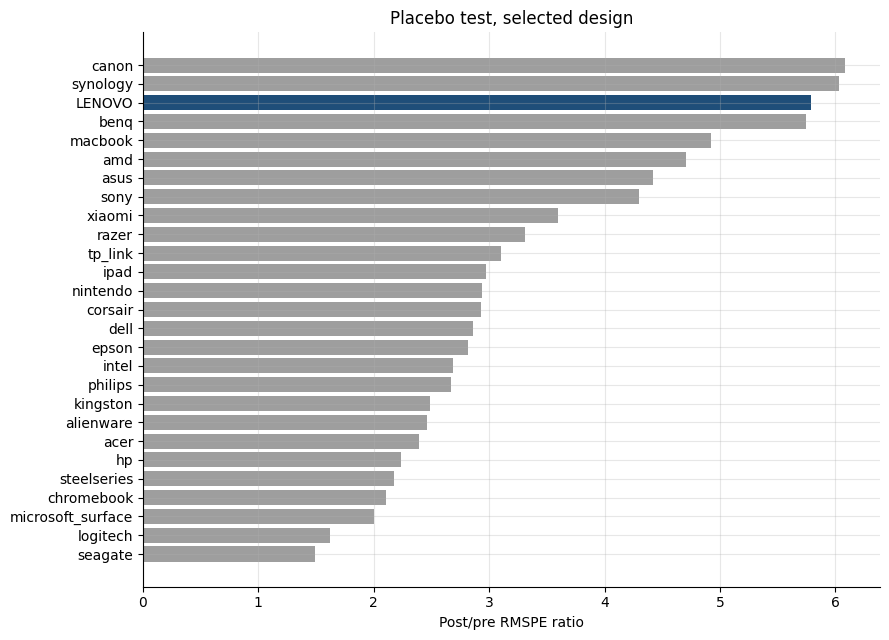

**Figure 4.** Rival brands diverging at least as much as Lenovo: synology, canon. Primary p = **0.111** with 26 placebos (threshold 0.10; smallest possible 0.037). Result: **does not pass** the pre-registered test.

In [8]:
pls = pd.DataFrame(p["placebos"]).sort_values("rmspe_ratio")
fig, ax = plt.subplots(figsize=(9, 6.5))
units = list(pls["placebo_unit"].str.replace("donor_", "")) + ["LENOVO"]
vals = list(pls["rmspe_ratio"]) + [p["treated_statistic"]]
order = np.argsort(vals)
ax.barh(np.array(units)[order], np.array(vals)[order],
        color=["#1f4e79" if u == "LENOVO" else "#9e9e9e" for u in np.array(units)[order]])
ax.set_xlabel("Post/pre RMSPE ratio")
ax.set_title("Placebo test, selected design")
plt.tight_layout(); plt.show()
above = pls.loc[pls["rmspe_ratio"] >= p["treated_statistic"], "placebo_unit"].str.replace("donor_", "").tolist()
md(f"**Figure 4.** Rival brands diverging at least as much as Lenovo: {', '.join(above) if above else 'none'}. "
   f"Primary p = **{fmt(p['p_value'], 3)}** with {p['placebos_kept']} placebos (threshold 0.10; smallest possible {fmt(1/(1+p['placebos_kept']), 3)}). "
   f"Result: **{'passes' if est['passes_primary_test'] else 'does not pass'}** the pre-registered test.")

### 5.3 Specification curve: does the conclusion depend on the design?

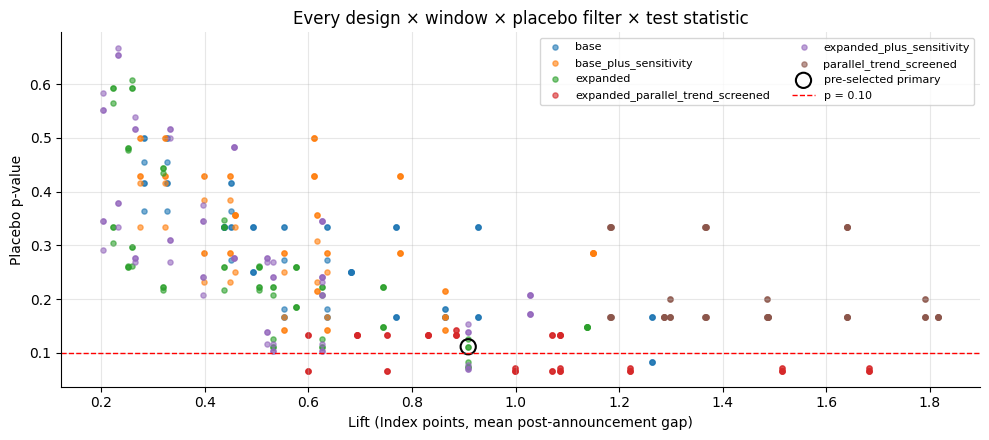

**Figure 5.** 432 specifications. The lift is positive in 100% of them (range +0.20 to +1.82), but only 11.1% reach p ≤ 0.10. Direction is robust; statistical separation from rival-brand drift is not.

In [9]:
curve = pd.read_parquet(E + "announcement_design_selection_v2/specification_curve.parquet")
fig, ax = plt.subplots(figsize=(10, 4.5))
for pool_name, group in curve.groupby("donor_pool"):
    ax.scatter(group["lift_index_points"], group["p_value"], s=14, alpha=0.6, label=pool_name)
prim = curve[curve["is_primary"]]
ax.scatter(prim["lift_index_points"], prim["p_value"], s=120, facecolors="none", edgecolors="black", lw=1.5, label="pre-selected primary")
ax.axhline(0.10, color="red", ls="--", lw=1, label="p = 0.10")
ax.set_xlabel("Lift (Index points, mean post-announcement gap)"); ax.set_ylabel("Placebo p-value")
ax.set_title("Every design × window × placebo filter × test statistic")
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()
s = est["specification_curve_summary"]
md(f"**Figure 5.** {s['specifications']} specifications. The lift is positive in {100*s['share_lift_positive']:.0f}% of them "
   f"(range {fmt(s['lift_range_index_points'][0], signed=True)} to {fmt(s['lift_range_index_points'][1], signed=True)}), "
   f"but only {100*s['share_p_at_or_below_alpha']:.1f}% reach p ≤ 0.10. Direction is robust; statistical separation from rival-brand drift is not.")

In [10]:
windows = curve[curve["selected_design"] & curve["placebo_filter"].eq("none")].pivot_table(
    index="window", columns="statistic", values=["lift_index_points", "p_value"])
windows.columns = [f"{a} ({b})" for a, b in windows.columns]
display(windows.style.format(precision=3))
md("**Table 3.** Selected design by post window. Excluding or stopping before the spring 2026 category surge lowers the lift; "
   "neither window passes the primary ratio test.")

,lift_index_points (mean_gap_over_pre_rmspe),lift_index_points (rmspe_ratio),p_value (mean_gap_over_pre_rmspe),p_value (rmspe_ratio)
window,,,,
all_post,0.909,0.909,0.074,0.111
before_spring_2026_surge,0.531,0.531,0.111,0.222
excluding_spring_2026_surge,0.626,0.626,0.111,0.222


**Table 3.** Selected design by post window. Excluding or stopping before the spring 2026 category surge lowers the lift; neither window passes the primary ratio test.

### 5.4 Media-value weighting (broadcast-inclusive exposure, ADR-0028)

In [11]:
mv = json.loads(Path(E + "sponsorship_counterfactual_v1/media_value_intensity_sensitivity.json").read_text())
display(pd.DataFrame([
    {"Weighting (49 weeks covered by media value)": "Media value (relative intensity, broadcast-inclusive)", "Mean gap (Index points)": mv["media_intensity_weighted_gap_index_points"]},
    {"Weighting (49 weeks covered by media value)": "Blinkfire FIFA impressions (digital)", "Mean gap (Index points)": mv["blinkfire_weighted_gap_same_window_index_points"]},
    {"Weighting (49 weeks covered by media value)": "Unweighted", "Mean gap (Index points)": mv["unweighted_mean_gap_same_window_index_points"]},
]).style.format({"Mean gap (Index points)": "{:+.3f}"}).hide(axis="index"))
coef = mv["timing_regression"]["coefficients"]["media_intensity_log_adstock_z"]
md(f"**Table 4.** {mv['window_start']} to {mv['window_end']}. Weeks with more broadcast-inclusive exposure do not show a larger gap; "
   f"the timing coefficient is {fmt(coef['estimate_index_points'], 3, True)} Index points per standard deviation (HAC s.e. {fmt(coef['hac_se'], 3)}). "
   "Media-value dollar amounts are never used (P1, ADR-0028).")

Weighting (49 weeks covered by media value),Mean gap (Index points)
"Media value (relative intensity, broadcast-inclusive)",+0.863
Blinkfire FIFA impressions (digital),+0.938
Unweighted,+0.806


**Table 4.** 2025-04-28 to 2026-03-30. Weeks with more broadcast-inclusive exposure do not show a larger gap; the timing coefficient is +0.018 Index points per standard deviation (HAC s.e. 0.104). Media-value dollar amounts are never used (P1, ADR-0028).

### 5.5 The spring 2026 category surge (a confounder)

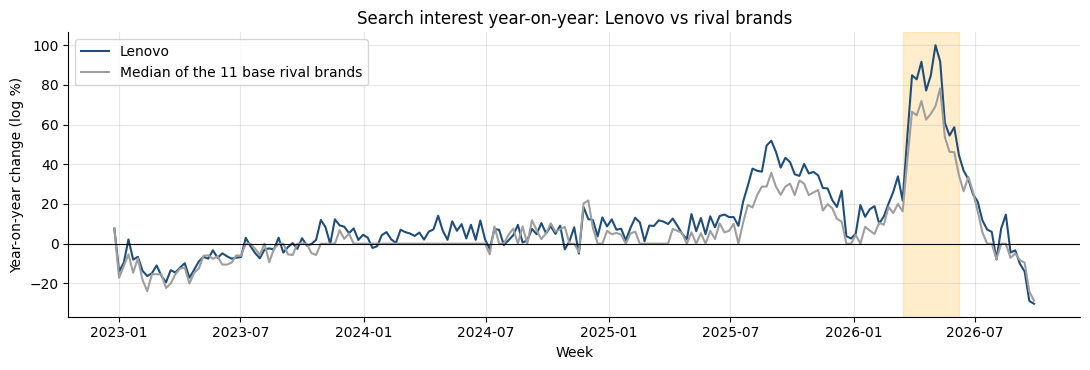

**Figure 6.** Orange band: spring 2026, when searches for every PC brand rose 60–100% year-on-year, consistent with the memory-shortage price rush. Lenovo reacts somewhat more strongly than rivals to category swings, so this surge inflates Lenovo's gap in that window independently of the sponsorship. The last weeks of any pull are provisional and are excluded from estimation.

In [12]:
base = registry.loc[registry["inclusion_policy"].eq("base"), "query_id"].tolist()
dp = donors.copy(); dp["week"] = pd.to_datetime(dp["week"])
pivot = dp[dp["query_id"].isin(base + ["anchor_lenovo"])].groupby(["week", "query_id"])["interest_common_scale"].mean().unstack()
yoy = 100 * np.log(pivot / pivot.shift(52))
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(yoy.index, yoy["anchor_lenovo"], label="Lenovo", color="#1f4e79")
ax.plot(yoy.index, yoy[base].median(axis=1), label="Median of the 11 base rival brands", color="#9e9e9e")
ax.axhline(0, color="black", lw=0.8)
ax.axvspan(pd.Timestamp("2026-03-15"), pd.Timestamp("2026-06-07"), color="orange", alpha=0.2)
ax.set_ylabel("Year-on-year change (log %)"); ax.set_xlabel("Week")
ax.set_title("Search interest year-on-year: Lenovo vs rival brands")
ax.legend(); plt.tight_layout(); plt.show()
md("**Figure 6.** Orange band: spring 2026, when searches for every PC brand rose 60–100% year-on-year, consistent with the memory-shortage "
   "price rush. Lenovo reacts somewhat more strongly than rivals to category swings, so this surge inflates Lenovo's gap in that window "
   "independently of the sponsorship. The last weeks of any pull are provisional and are excluded from estimation.")

## 6. Interpretation

In [13]:
from srmp.experiments.brand_value_dominance_v1 import _salience_map
smap = _salience_map("data/curated/index/brand_index_weekly.parquet", "data/curated/trends/trends_weekly_averaged.parquet", "brand_lenovo")
lift = p["lift_index_points"]
cf_level = target[~pre].mean() - lift          # selected design's synthetic level after the announcement
pct = 100 * lift / (cf_level - smap["zero_interest_index_level"])
md(f"""- **Direction:** positive. Across {s['specifications']} specifications the post-announcement lift is never negative.
- **Magnitude:** the pre-selected design gives **{fmt(lift, signed=True)} Brand Index points** averaged over {int((~pre).sum())} post-announcement weeks
  (21 Oct 2024 to {panel.index.max().date()}). Because the Index is an exact linear function of Lenovo's search interest
  (zero searches = {fmt(smap['zero_interest_index_level'])} on the Index), this is about **{fmt(pct, 1, True)}% more brand search salience**
  than the synthetic no-sponsorship path (about {fmt(cf_level, 1)} on the Index).
- **Reference case:** a weighted mix of rival tech brands chosen on pre-announcement fit only.
- **Uncertainty:** the primary placebo test gives p = {fmt(p['p_value'], 3)} — {'below' if p['p_value'] <= 0.10 else 'just above'} the 0.10 threshold.
  Rival brands such as {', '.join(above[:3])} drift as far from their own twins over the same two years.
- **Decision relevance:** the lift is consistent and plausibly sponsorship-related, but it is **not yet statistically confirmed**. It should be reported
  as a borderline, directionally robust result, and should not feed a valuation as an accepted attribution. The pre-registered World Cup
  persistence window (closing 18 Oct 2026) is the next confirmatory test.""")

- **Direction:** positive. Across 432 specifications the post-announcement lift is never negative.
- **Magnitude:** the pre-selected design gives **+0.91 Brand Index points** averaged over 100 post-announcement weeks
  (21 Oct 2024 to 2026-09-14). Because the Index is an exact linear function of Lenovo's search interest
  (zero searches = 80.61 on the Index), this is about **+9.6% more brand search salience**
  than the synthetic no-sponsorship path (about 90.1 on the Index).
- **Reference case:** a weighted mix of rival tech brands chosen on pre-announcement fit only.
- **Uncertainty:** the primary placebo test gives p = 0.111 — just above the 0.10 threshold.
  Rival brands such as synology, canon drift as far from their own twins over the same two years.
- **Decision relevance:** the lift is consistent and plausibly sponsorship-related, but it is **not yet statistically confirmed**. It should be reported
  as a borderline, directionally robust result, and should not feed a valuation as an accepted attribution. The pre-registered World Cup
  persistence window (closing 18 Oct 2026) is the next confirmatory test.

## 7. Limitations and non-claims

- **Constructed outcome, not survey brand equity.** The Brand Index measures search salience. It does not establish changes in awareness, consideration, preference or purchase.
- **Association, not proven causation.** The synthetic control is a causal design, but with p above the threshold the result is not distinguishable from normal relative drift among tech brands. It does not prove the sponsorship caused the lift.
- **Confounding remains.** The spring 2026 PC-price surge, Lenovo-specific news (record results, share-price rally) and product launches all fall in the post period. Event-week controls and window exclusions reduce but do not remove this.
- **In-sample design, single treated unit.** The design was selected on pre-period fit; the post-period is a single realisation for one brand.
- **Donor screening is evidence-bounded.** "No FIFA sponsorship found" is not proof of none.
- **Digital-only exposure.** Blinkfire excludes broadcast; media value covers only May 2025–April 2026.
- **Provisional data.** The last two weeks of every Google Trends pull are revised and excluded; the next pull will change the latest weeks.
- **Statistical vs unmodelled uncertainty.** Placebo p-values capture rival-brand drift; they do not capture Trends sampling error, index calibration error or donor-screening mistakes.

## Next steps

1. Run the pre-registered World Cup persistence test after 18 October 2026 (see `20_world_cup_impact_interim.ipynb`).
2. Obtain GWI Q2/Q3 2026 waves to test the lift on survey-based brand metrics rather than search.
3. Keep this notebook synchronized: re-run it after every pipeline rebuild (`python -m srmp.review`).